# Crypto Perpetuals: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error in
it is silent where it is made and reaches every metric and every backtest after it. This
notebook fixes the execution convention, proves each labelled row has a complete forward
window, measures how much independent information those rows carry, establishes what the
simplest signal already earns against the label, and writes the label files the rest of the
case study trains against.

## Learning objectives

- Move a provider's bar-open timestamps onto the clock at which each bar is actually known,
  and express a forward return from that boundary
- Measure a forward window on the price series the return is taken from, so that a gap in a
  predictor cannot decide whether a label exists
- Assert, rather than describe, that every labelled row has a gap-free window inside one
  symbol, and account for every row that carries no label
- Restrict a diagnostic to the rows whose outcome is already known when the holdout begins,
  which is not the same as the rows observed before it
- Measure how much independent information overlapping forward windows carry, both as a
  decay curve and as an effective row count
- Measure what the simplest declared signal earns against the label, under a standard error
  that accounts for dependence between consecutive measurements

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the Binance eight-hourly perpetual bars through
`load_crypto_perps()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, the horizons and the holdout boundary.
Writes `labels/fwd_ret_8h.parquet`, `labels/fwd_ret_24h.parquet`, `labels/fwd_dir_8h.parquet`
and `labels/fwd_dir_8h_3c.parquet`.

`04_model_based_features.py` reads the primary label file directly; `05_evaluation.py` and
the modelling notebooks read it through `utils/modeling.py::load_modeling_dataset`. The
walk-forward folds every one of them trains on are derived from the timeline of that same
file by `case_studies/utils/cv_window.py`.

In [1]:
"""Crypto Perps Funding: Label Engineering."""

import warnings
from datetime import UTC, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.artifact_quality import quality_report, render_quality_report
from case_studies.utils.feature_engineering import rolling_zscore
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_crypto_perps
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "crypto_perps_funding"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the history
to a later start; `MAX_SYMBOLS` keeps only the first symbols in alphabetical order. Either one
shortens a run, at the cost of a thinner cross-section for the rank correlation in Section G.

In [2]:
MAX_SYMBOLS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A horizon
or a boundary typed into a cell is a second copy of a value the rest of the pipeline reads
from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and both
are declared in hours. Dividing by the length of a bar turns each into a number of settlement
periods, which is the unit a shift counts in. A day is three settlement periods on this grid,
and Section G's two smoothing windows are counted in days for the same reason: expressed that
way they stay right if the exchange ever changes how often it settles.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
BAR_HOURS = setup["features"]["bar_hours"]
PER_DAY = 24 // BAR_HOURS

PRIMARY_LABEL = setup["labels"]["primary"]
VARIANT_LABEL = setup["labels"]["variants"][0]
RETURN_LABELS = [PRIMARY_LABEL, VARIANT_LABEL]
BINARY_LABEL, THREE_CLASS_LABEL = setup["labels"]["variants"][1:]
ALL_LABELS = [*RETURN_LABELS, BINARY_LABEL, THREE_CLASS_LABEL]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Hh")) // BAR_HOURS
    for name in RETURN_LABELS
}
window = setup["evaluation"]
HOLDOUT_START = datetime.fromisoformat(window["holdout_start"]).replace(tzinfo=UTC)
WINDOW_END = datetime.fromisoformat(window["holdout_end"]).replace(tzinfo=UTC) + timedelta(days=1)

for name, horizon in HORIZONS.items():
    print(
        f"{name}: the return over {horizon} settlement period(s) of {BAR_HOURS} hours each, so "
        f"{horizon * BAR_HOURS} hours of price must follow a row before it can carry this label."
    )
print(
    f"{BINARY_LABEL} and {THREE_CLASS_LABEL} discretise {PRIMARY_LABEL}, the primary label a "
    f"stage trains on unless it names another, so all three resolve at the same time."
)
print(
    f"The holdout runs from {HOLDOUT_START.date()}; a row enters a diagnostic here only where its "
    f"own forward window closes before that date."
)

fwd_ret_8h: the return over 1 settlement period(s) of 8 hours each, so 8 hours of price must follow a row before it can carry this label.
fwd_ret_24h: the return over 3 settlement period(s) of 8 hours each, so 24 hours of price must follow a row before it can carry this label.
fwd_dir_8h and fwd_dir_8h_3c discretise fwd_ret_8h, the primary label a stage trains on unless it names another, so all three resolve at the same time.
The holdout runs from 2024-01-01; a row enters a diagnostic here only where its own forward window closes before that date.


## A. The learning task

A perpetual future is a derivative contract with no expiry date. Nothing forces its price
back to the spot market the way a delivery date does, so the exchange makes one side pay the
other at fixed intervals instead: every eight hours, holders of the crowded side of the
contract pay holders of the other. That payment is called funding, and its size tracks the
*premium index*, the gap between what the perpetual trades at and what the underlying trades
at.

The hypothesis is that this premium is a crowding measure that mean reverts. When the premium
index sits far above its own recent level, longs are paying to hold the contract, and the
perpetual price is expected to give ground relative to the rest of the universe. The label is
therefore a forward price return on the perpetual itself, ranked across symbols rather than
judged in isolation.

The decision cadence comes from the market's own settlement rhythm. Binance settles funding
every eight hours, the premium index is published on that grid, and a decision can be acted
on at each settlement, which fixes the primary horizon at one period. The variant asks
whether the same relationship pays over three periods. That is a question about how long the
crowding takes to unwind, and about how often a strategy would have to trade, rather than a
second hypothesis.

One thing the label is not: the funding payment. The premium index predicts funding without
being it, because the realized rate adds an interest component and exchange clamps. A
strategy that collects funding is a separate construction on the funding-rate series, and
this label cannot measure it.

## B. Preparation before the label

One series carries everything the label needs. `load_crypto_perps` returns the eight-hourly
perpetual bars with the premium index published on the same settlement grid alongside them,
so the price the return is measured from and the predictor Section G ranks on are columns of
a single frame. `03_financial_features` builds every feature from this same call.

A forward window is meaningful only on a series whose timestamps mean what the label assumes.
Binance stamps each row with the time its bar **opened**, so a row stamped midnight reports a
close and a premium that nobody knows until eight hours later. The series is therefore
advanced by one bar length before anything is shifted or filtered, and the resulting
`timestamp` is the boundary at which the completed bar's close and premium are jointly
available. Building the label on the provider's clock would pair a predictor with a return
that had already happened.

No eligibility filter runs before the shift, and that ordering matters: dropping rows first
makes a shift count surviving rows, so the horizon stops being measured in settlement periods
and the window silently spans whatever was removed. The same reasoning settles which series
the window is measured on. This label is a forward return on the perpetual, so whether its
window is complete is a property of the perpetual's own bars. Measuring it on a frame the
premium index had been joined into would let a settlement the index skipped null a label
whose two prices both exist - the index is absent at some settlements where the contract
traded, so the two are not the same set of rows.

The universe is a fixed nineteen-symbol research panel rather than a point-in-time liquidity
ranking, a selection bias `01_feasibility_analysis` documents and this notebook inherits.

The settlement grid is asserted rather than assumed. The labels below are built by comparing
a shifted timestamp against `t` plus a horizon, so a stamp off the grid would null a label
that is in fact well defined. Duplicate keys are checked as well, because a duplicated key
multiplies rows and every shift past it is then measured across the wrong pair of bars. The
third assertion is what lets Section D account for an unlabelled row by its window alone: a
bar the exchange published always carries a close, so no row is unlabelled for want of a
price at its own timestamp.

In [4]:
available_at = (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
bars = (
    load_crypto_perps(frequency=f"{BAR_HOURS}h", start_date=START_DATE)
    .with_columns(available_at)
    .filter(pl.col("timestamp") < WINDOW_END)
    .sort(["symbol", "timestamp"])
)
if MAX_SYMBOLS is not None:
    bars = bars.filter(pl.col("symbol").is_in(sorted(bars["symbol"].unique())[:MAX_SYMBOLS]))

stamps = bars["timestamp"].dt.hour().unique().sort().to_list()
assert stamps == list(range(0, 24, BAR_HOURS)), f"off-grid stamps {stamps}"
assert bars.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "repeated key"
assert bars["close"].null_count() == 0, "a published bar with no close"

MARKET_DATA_DIGEST = value_digest(bars, ["symbol", "timestamp", "close"])

print(
    f"{bars['symbol'].n_unique()} symbols, {bars.height:,} bars on the availability clock, "
    f"{bars['timestamp'].min()} to {bars['timestamp'].max()}"
)
no_premium = bars["premium_index_close"].null_count()
print(f"Bars that quote a price with no premium index published alongside them: {no_premium}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

19 symbols, 108,298 bars on the availability clock, 2020-01-01 08:00:00+00:00 to 2025-12-31 16:00:00+00:00
Bars that quote a price with no premium index published alongside them: 537
market_data digest: edcb32a5f34e066e


## C. Label construction

One execution convention, written once and applied at both horizons:

$$r^{(h)}_{i,t} = \frac{C_{i,t+h}}{C_{i,t}} - 1$$

where $C$ is the perpetual close of the bar that completed at the subscripted time, and
$t+h$ is $h$ settlement periods later for symbol $i$. That is Chapter 7.2's close-to-close
convention, on a grid where both ends are prices the market printed. Because the grid is
exact, the endpoint is required to land on `t` plus the horizon, and a row whose next stamp
does not is left null instead of labelled across the hole.

The same exactness is what makes `slot` well defined: with every stamp on the grid the
assertion above checks, hours since a symbol's first bar divide by the period without
remainder, so `slot` is the settlement the row sits on rather than its position among the
rows that happen to survive. Section F's overlap statistics are counted on it, and Section D
counts how many settlements are absent. `slot` and `from_end` are working columns; the label
files carry the timestamp, the symbol and the label.

The digest recorded above becomes every label's `inputs` entry. It covers the keys and the one
price column this formula reads, so a re-run against a refreshed download is distinguishable
from a re-run against the same one.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` settlement periods, null across a grid hole."""
    span = pl.col("timestamp") + pl.duration(hours=BAR_HOURS * horizon)
    return df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end"),
        pl.col("close").shift(-horizon).over("symbol").alias("_close_end"),
    ).with_columns(
        pl.when(pl.col("_label_end") == span)
        .then(pl.col("_close_end") / pl.col("close") - 1)
        .otherwise(None)
        .alias(name)
    )


from_end = pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")
elapsed = pl.col("timestamp") - pl.col("timestamp").min().over("symbol")
slot = (elapsed.dt.total_hours() // BAR_HOURS).cast(pl.Int64)
labels_df = bars.with_columns(from_end.alias("from_end"), slot.alias("slot"))
for name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, name).drop(["_label_end", "_close_end"])
labels_df = labels_df.with_columns(
    pl.col("timestamp").shift(-HORIZONS[PRIMARY_LABEL]).over("symbol").alias("_label_end")
)

The two direction labels are the same return, discretised. A Polars comparison propagates
nulls, so casting `ret > 0` to an integer keeps the unlabelled rows unlabelled. The
`when(ret > 0).then(1).otherwise(0)` form does not: a null predicate is not true, the
`otherwise` branch fires, and every row with no forward window at all joins the "down" class
as a fabricated outcome.

The three-class label cuts at the terciles of the development sample. Two constants applied to
every row make the classes balanced over that sample by construction, so the balance is not
evidence about the label; the year-by-year figure in Section E is what shows the cut's
behaviour, and the known limitations record what a fold-local calibration would change.

In [6]:
dev_primary = labels_df.filter(pl.col("_label_end") < HOLDOUT_START).drop_nulls(PRIMARY_LABEL)
p33 = dev_primary[PRIMARY_LABEL].quantile(0.33)
p67 = dev_primary[PRIMARY_LABEL].quantile(0.67)

labels_df = labels_df.with_columns(
    (pl.col(PRIMARY_LABEL) > 0).cast(pl.Int8).alias(BINARY_LABEL),
    pl.when(pl.col(PRIMARY_LABEL).is_null())
    .then(None)
    .when(pl.col(PRIMARY_LABEL) > p67)
    .then(1)
    .when(pl.col(PRIMARY_LABEL) < p33)
    .then(-1)
    .otherwise(0)
    .cast(pl.Int8)
    .alias(THREE_CLASS_LABEL),
)
print(f"Constructed {', '.join(ALL_LABELS)}")
print(f"Development terciles: {p33:.6f} and {p67:.6f}")

Constructed fwd_ret_8h, fwd_ret_24h, fwd_dir_8h, fwd_dir_8h_3c
Development terciles: -0.008188 and 0.008380


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity the
label claims. Each property below fails silently and leaves plausible numbers behind, so each
is asserted rather than described.

The third assertion is a full reconciliation rather than a bound. Every row that carries no
label is attributed to exactly one cause - the tail of its symbol's series, or a settlement
missing from the grid inside it - and the labelled rows plus those two counts have to sum to
the height of the frame. A label that crossed a symbol boundary, or a short label masked by a
longer one's null set, would break that identity.

In [7]:
for name, horizon in HORIZONS.items():
    span = pl.col("timestamp") + pl.duration(hours=BAR_HOURS * horizon)
    checked = forward_return(labels_df.drop("_label_end"), horizon, "_check")
    tail = pl.col("from_end") < horizon
    landed = pl.col("_label_end") == span
    causes = {"tail": tail, "grid hole": ~tail & ~landed}
    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)["_check"].null_count() == checked.filter(tail).height
    # 2. Every labelled window spans exactly its horizon on the settlement grid.
    assert checked.drop_nulls("_check").filter(~landed).height == 0
    # 3. Labelled rows plus the two causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    labelled = checked["_check"].count()
    assert labelled + sum(counts.values()) == checked.height, (name, counts)
    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(f"{name}: {labelled:,} labelled; unlabelled {unlabelled}")

# 4. A null return must not reach a discrete label.
nulls = {n: labels_df[n].null_count() for n in ALL_LABELS}
assert nulls[BINARY_LABEL] == nulls[THREE_CLASS_LABEL] == nulls[PRIMARY_LABEL], nulls
print(f"Both direction labels null exactly where {PRIMARY_LABEL} does")

fwd_ret_8h: 108,271 labelled; unlabelled 19 tail, 8 grid hole
fwd_ret_24h: 108,217 labelled; unlabelled 57 tail, 24 grid hole
Both direction labels null exactly where fwd_ret_8h does


Position zero below is each symbol's last available bar. The non-null rate has to fall to
zero over exactly the last `horizon` positions and sit flat beyond them. A scalar count of
valid rows shows neither failure this catches: a tail fabricated instead of nulled, or a
short label masked by a longer one's null set. Beyond the horizon the rate is one at every
position drawn: the grid holes Section D counts are too rare to fall in these last few
positions of any symbol, so they show up in that section's counts and not here.

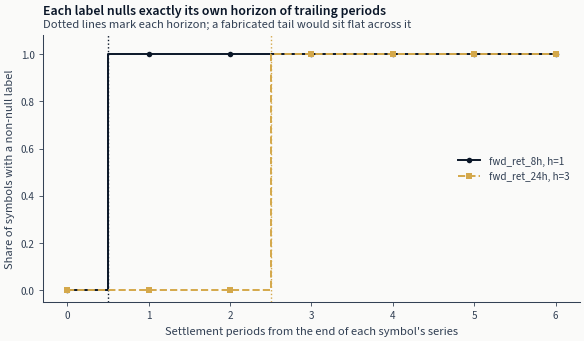

In [8]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in RETURN_LABELS])
    .sort("from_end")
)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(
    RETURN_LABELS, (COLORS["blue"], COLORS["amber"]), ("o-", "s--"), strict=True
):
    label = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", color=colour, label=label)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Settlement periods from the end of each symbol's series")
ax.set_ylabel("Share of symbols with a non-null label")
ax.set_ylim(-0.05, 1.08)
note = "Dotted lines mark each horizon; a fabricated tail would sit flat across it"
add_message_title(ax, "Each label nulls exactly its own horizon of trailing periods", subtitle=note)
ax.legend(loc="center right", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing in every regime? Everything from
here through Section G is computed on the development window only, cut on the label's
**endpoint** rather than on its observation date: a row observed shortly before the holdout
still resolves inside it, so a filter on the observation date admits rows whose outcome was
not yet known. The label files keep every row, because the restriction governs what this
notebook looks at rather than what it writes.

In [9]:
dev = {
    name: forward_return(labels_df.drop("_label_end"), horizon, "_check")
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for name, frame in dev.items():
    print(f"{name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_8h: 66,604 development rows through 2023-12-31 08:00:00+00:00
fwd_ret_24h: 66,550 development rows through 2023-12-30 16:00:00+00:00


Both return labels go on one axis with identical bins and a logarithmic count axis. The
difference that matters is not the width, which two dispersion scalars would carry, but the
shape: the longer horizon puts far more mass past the right edge of the axis than past the left,
which is the asymmetry its skew reports and no table of moments shows. The axis is symmetric and
narrower than either label's range, so the rows outside it are counted on each side below rather
than drawn.

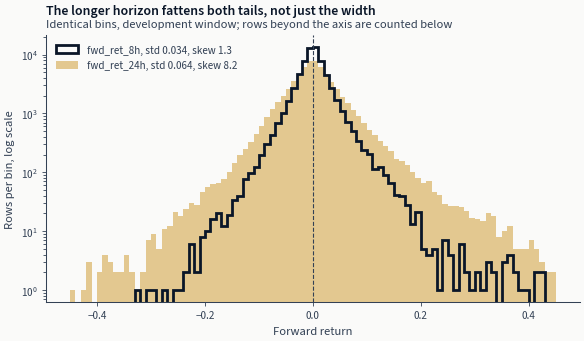

fwd_ret_8h: std 0.03417, skew 1.31, 0 left 4 right of axis
fwd_ret_24h: std 0.06424, skew 8.20, 5 left 46 right of axis


In [10]:
bins = np.linspace(-0.45, 0.45, 91)
styles = {
    VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.6, zorder=1),
    PRIMARY_LABEL: dict(color=COLORS["blue"], histtype="step", lw=2, zorder=2),
}
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in (PRIMARY_LABEL, VARIANT_LABEL):
    series = dev[name][name]
    label = f"{name}, std {series.std():.3f}, skew {series.skew():.1f}"
    ax.hist(series.to_numpy(), bins=bins, label=label, **styles[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return")
ax.set_ylabel("Rows per bin, log scale")
note = "Identical bins, development window; rows beyond the axis are counted below"
add_message_title(ax, "The longer horizon fattens both tails, not just the width", subtitle=note)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Histograms of both labels on identical bins and a log count axis.")

for name in RETURN_LABELS:
    col, series = pl.col(name), dev[name][name]
    lo, hi = dev[name].filter(col < bins[0]).height, dev[name].filter(col > bins[-1]).height
    print(f"{name}: std {series.std():.5f}, skew {series.skew():.2f}, {lo} left {hi} right of axis")

Chapter 7.2 asks for base rates tracked through time, and for a discrete label that means the
class fractions period by period. The cuts here are two constants, so what moves between
years is the volatility of the underlying return, and the middle class absorbs it.

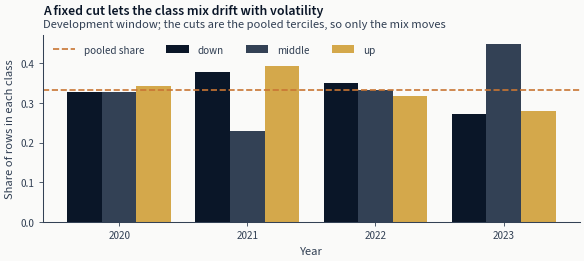

fwd_dir_8h_3c middle share runs 0.229 to 0.448 by year


In [11]:
annual = (
    dev[PRIMARY_LABEL]
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by(["year", THREE_CLASS_LABEL])
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / pl.col("n").sum().over("year")).alias("fraction"))
    .sort("year")
)
years = annual["year"].unique().sort().to_list()
classes = {
    -1: ("down", COLORS["blue"]),
    0: ("middle", COLORS["neutral"]),
    1: ("up", COLORS["amber"]),
}

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
for offset, (cls, (cls_name, colour)) in enumerate(classes.items()):
    rows = annual.filter(pl.col(THREE_CLASS_LABEL) == cls).sort("year")
    x = np.arange(len(years)) + (offset - 1) * 0.27
    ax.bar(x, rows["fraction"].to_numpy(), 0.27, color=colour, label=cls_name)
ax.axhline(1 / 3, color=COLORS["copper"], linestyle="--", lw=1.2, label="pooled share")
ax.set_xticks(np.arange(len(years)), [str(year) for year in years])
ax.set_xlabel("Year")
ax.set_ylabel("Share of rows in each class")
note = "Development window; the cuts are the pooled terciles, so only the mix moves"
add_message_title(ax, "A fixed cut lets the class mix drift with volatility", subtitle=note)
ax.legend(loc="upper left", frameon=False, ncols=4)
show_with_alt(fig, "Class shares of the three-class label, year by year.")

middle = annual.filter(pl.col(THREE_CLASS_LABEL) == 0)["fraction"]
print(f"{THREE_CLASS_LABEL} middle share runs {middle.min():.3f} to {middle.max():.3f} by year")

On the development window the eight-hour label has a standard deviation of 0.03417 and a skew
of 1.31. The twenty-four-hour label is 0.06424 wide, close to the square root of three its
horizon implies, but its skew is 8.20 and the extra mass is one-sided. The three-class label
is balanced over the pooled sample by construction and not within any single year: its middle
class runs from 0.229 of the rows to 0.448 across the four development years.

## F. Overlap and effective sample size

Sampling a multi-period label at every period makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is counted.
`effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per symbol,
because concurrency is a property of one symbol's own overlapping windows.

The one-period label is the case that checks the measurement rather than the data. Consecutive
one-period forward returns are built from disjoint return intervals, so no row shares any part
of its window with a neighbour, every uniqueness weight must be 1, and the effective count has
to come back equal to the row count. A weighting that counted the anchor bar as consumed would
halve it instead, and would read as a refinement.

Disjoint is not independent, and the figure below is what says so: the one-period label shares
no part of its window with any other row, and its autocorrelation is still not zero. Average
uniqueness discounts shared windows, not serial dependence, so nothing measured here discounts
the second, and a fold gap sized from the horizon does not either.

Both statistics are counted on `slot`, the settlement each row sits on, so the holes Section D
counts stay holes: a pair enters the autocorrelation only where two settlements are exactly the
lag apart, and a window's uniqueness is weighted over the settlements it actually spans. That is
also why the variant's ratio sits just above 1/h rather than matching it to four decimals - a
hole ends an overlap early, and the rows either side of it keep evidence a fully overlapped
window would have shared away.

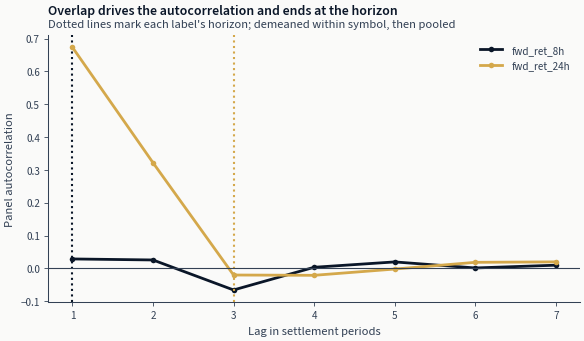

fwd_ret_8h: N=66,604, N_eff=66,604, ratio 1.000 against 1.000 for windows overlapping this fully; autocorrelation 0.029 at lag one, 0.029 at its horizon
fwd_ret_24h: N=66,550, N_eff=22,201, ratio 0.334 against 0.333 for windows overlapping this fully; autocorrelation 0.673 at lag one, -0.020 at its horizon


In [12]:
max_lag = HORIZONS[VARIANT_LABEL] + 4
acf = {n: panel_autocorrelation(dev[n], n, max_lag=max_lag, bar_col="slot") for n in RETURN_LABELS}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(RETURN_LABELS, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.plot(np.arange(1, max_lag + 1), acf[name], marker="o", color=colour, lw=2, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in settlement periods")
ax.set_ylabel("Panel autocorrelation")
note = "Dotted lines mark each label's horizon; demeaned within symbol, then pooled"
add_message_title(ax, "Overlap drives the autocorrelation and ends at the horizon", subtitle=note)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of both labels against lag in periods.")

for name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[name], horizon=horizon, bar_col="slot")
    print(
        f"{name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.3f} against "
        f"{1 / horizon:.3f} for windows overlapping this fully; autocorrelation "
        f"{acf[name][0]:.3f} at lag one, {acf[name][horizon - 1]:.3f} at its horizon"
    )

The eight-hour label's 66,604 development rows carry 66,604 effective observations: at a
one-period horizon consecutive windows are disjoint, which is the answer that confirms the
weighting rather than the data. The twenty-four-hour label's 66,550 rows carry 22,201, a ratio
of 0.334 against the 0.333 a fully overlapped three-period window implies, and its
autocorrelation falls from 0.673 at lag one to -0.020 at lag three. The purge gap a fold needs
is set by the forward window itself, not by this count.

## G. Baseline floor

One signal against the primary label on the development window, with no feature engineering:
the rolling z-score of the premium index that `setup.yaml` names as the treatment, and that
`03_financial_features` recomputes under that name from the same helper called here. Measuring
what the simplest declared signal already earns, before building features, is what makes a
later improvement meaningful.

The information coefficient is the cross-sectional rank correlation at each settlement,
averaged over settlements, which is the quantity a ranking model is scored on. The library
call keeps its output ordered by time, which the standard error depends on. The minimum
cross-section is half the median rather than a bare count, so it means the same thing on a
universe of another size, and a settlement below it carries no correlation at all - the count
printed is the number of settlements that entered the statistic, not the number in the window.

The standard error is Newey-West over one day of settlements. The horizon alone would set the
bandwidth to zero and apply no correction: the primary label does not overlap, but its IC
series is still serially dependent, because the premium z-score that produces it moves slowly.

In [13]:
ZSCORE_BARS = setup["features"]["windows"]["premium_zscore"]["14d"]
TREATMENT = setup["causal"]["treatment"]
ZSCORE_CLIP = setup["features"]["clip"]["zscore"]

baseline = (
    labels_df.with_columns(
        rolling_zscore("premium_index_close", ZSCORE_BARS, "symbol")
        .clip(-ZSCORE_CLIP, ZSCORE_CLIP)
        .alias("premium_z")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls([PRIMARY_LABEL, "premium_z"])
)
median_cross_section = int(baseline.group_by("timestamp").len()["len"].median())
ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="premium_z",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=median_cross_section // 2,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", maxlags=PER_DAY)

print(
    f"Baseline: {ZSCORE_BARS}-period premium z-score, the feature {TREATMENT}, against "
    f"{PRIMARY_LABEL}: {baseline.height:,} rows, median cross-section {median_cross_section}"
)
print(
    f"  settlements scored {stats['n_periods']:,} of {ic.height:,} in the window; the rest had "
    f"fewer than {median_cross_section // 2} symbols quoting and carry no correlation"
)
print(f"  mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: 42-period premium z-score, the feature premium_zscore_14d, against fwd_ret_8h: 62,997 rows, median cross-section 16
  settlements scored 3,655 of 4,243 in the window; the rest had fewer than 8 symbols quoting and carry no correlation
  mean IC -0.0352
  HAC t -7.92 on 3 Bartlett lags, naive t -7.90, p 3.21e-15


A mean cannot say whether a relationship is present throughout the window or concentrated in
one episode, and only the second would make the baseline an artifact of a single regime. The
smoothing window below is thirty days of settlements.

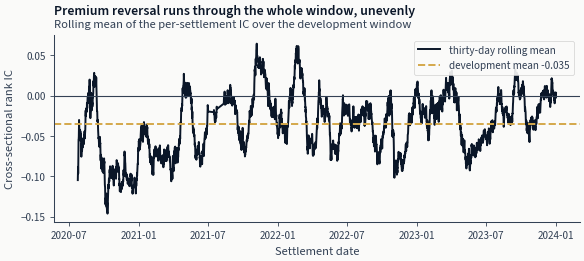

In [14]:
IC_SMOOTHING = 30 * PER_DAY
smooth = pl.col("ic").rolling_mean(IC_SMOOTHING, min_samples=IC_SMOOTHING // 3).alias("ic_smooth")
rolling_ic = ic.with_columns(smooth).drop_nulls("ic_smooth")
mean_ic = stats["mean_ic"]

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.plot(
    rolling_ic["timestamp"].to_list(),
    rolling_ic["ic_smooth"].to_numpy(),
    color=COLORS["blue"],
    label="thirty-day rolling mean",
)
ax.axhline(mean_ic, color=COLORS["amber"], linestyle="--", label=f"development mean {mean_ic:+.3f}")
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Settlement date")
ax.set_ylabel("Cross-sectional rank IC")
note = "Rolling mean of the per-settlement IC over the development window"
add_message_title(ax, "Premium reversal runs through the whole window, unevenly", subtitle=note)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
show_with_alt(fig, "Rolling mean of the per-settlement rank IC over the window.")

The premium z-score earns a mean IC of -0.0352 against the eight-hour label, negative as a
reversal signal implies. Under the naive standard error that is a t-statistic of -7.90; with
three Newey-West lags it is -7.92, and the two agree because the correction is small at this
bandwidth. That -0.0352 is what a feature has to improve on, measured over the 3,655
settlements whose cross-section reached the eight-symbol minimum, on a universe whose median
cross-section is 16 symbols.

## H. Artifacts and the audit record

Each label goes to its own parquet file, and beside each one the notebook writes a small JSON
file describing what that parquet holds. Its purpose is to make a label file identifiable
after the fact, so that two runs which produced different values can be told apart even when
the files have the same shape and size. It records a digest of the values written, so any
changed value changes the digest; the number of rows; the columns that identify a row; the
notebook that wrote it; and a digest of the price data the label was built from, which is
what ties a label to its data vintage.

The walk-forward folds that train models are derived per label by
`case_studies/utils/cv_window.py` from `config/setup.yaml` and the timeline of the parquet
written here, so which rows land in these files is what sets where the fold boundaries fall.

In [15]:
for name in ALL_LABELS:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", name]).drop_nulls(),
        LABELS_DIR / f"{name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_8h.parquet: 108,271 rows, digest 4091274639762d69
fwd_ret_24h.parquet: 108,217 rows, digest 875a930d647608c2
fwd_dir_8h.parquet: 108,271 rows, digest 0d16a715c94335bd
fwd_dir_8h_3c.parquet: 108,271 rows, digest 4686b2bd6c35e7a8


The record Chapter 7.2 requires to close a label definition, one row per label, built from the
values computed above rather than written by hand.

In [16]:
base_rates = {
    PRIMARY_LABEL: f"mean {dev[PRIMARY_LABEL][PRIMARY_LABEL].mean():+.5f}",
    VARIANT_LABEL: f"mean {dev[VARIANT_LABEL][VARIANT_LABEL].mean():+.5f}",
    BINARY_LABEL: f"up share {dev[PRIMARY_LABEL][BINARY_LABEL].mean():.4f}",
    THREE_CLASS_LABEL: f"cut at {p33:.6f} and {p67:.6f} on the pooled development sample",
}
readers = dict.fromkeys(
    ALL_LABELS, "the modelling notebooks, as a variant declared in `setup.yaml`"
)
readers[PRIMARY_LABEL] = "04_model_based_features.py, 05_evaluation.py and the modelling notebooks"
print("\nLabel audit record")
for name, base in base_rates.items():
    horizon = HORIZONS.get(name, HORIZONS[PRIMARY_LABEL])
    print(
        f"\n{name}\n  anchor       perpetual close of the bar completing at t"
        f"\n  horizon      {horizon} settlement periods, {horizon * BAR_HOURS} hours"
        f"\n  resolution   fixed at t+h; a timestamp names the boundary at which its own bar"
        f"\n               closed, so no intraday tie-break arises"
        f"\n  overlap      {horizon - 1} periods shared by consecutive rows"
        f"\n  base rate    {base}\n  consumed by  {readers[name]}"
    )


Label audit record

fwd_ret_8h
  anchor       perpetual close of the bar completing at t
  horizon      1 settlement periods, 8 hours
  resolution   fixed at t+h; a timestamp names the boundary at which its own bar
               closed, so no intraday tie-break arises
  overlap      0 periods shared by consecutive rows
  base rate    mean +0.00098
  consumed by  04_model_based_features.py, 05_evaluation.py and the modelling notebooks

fwd_ret_24h
  anchor       perpetual close of the bar completing at t
  horizon      3 settlement periods, 24 hours
  resolution   fixed at t+h; a timestamp names the boundary at which its own bar
               closed, so no intraday tie-break arises
  overlap      2 periods shared by consecutive rows
  base rate    mean +0.00303
  consumed by  the modelling notebooks, as a variant declared in `setup.yaml`

fwd_dir_8h
  anchor       perpetual close of the bar completing at t
  horizon      1 settlement periods, 8 hours
  resolution   fixed at t+h; a ti

## What the labels hold, and what they owe

Two questions about the files this stage just wrote, and the rows that are there answer only one
of them. The first is what is in each column - nulls, how much sits at exactly zero, how far the
extreme values are from the body, whether anything is constant. A threshold crossed there asks
for a sentence and settles nothing on its own: half the rows at zero is a defect in a return and
is what a balanced direction label is meant to look like.

The second is coverage, and it needs a denominator that is not the labels themselves. **The
reference is `bars`** - every settlement period a perpetual actually traded in, which is the set
a forward return could in principle have been computed on. Comparing one label to the other
three would hide any period where all four are absent together; comparing them to the bar panel
cannot.

A percentage alone decides nothing, so each label declares where it is entitled to be short
before the number is printed. A forward return owes no value in the last `horizon` settlement
periods of a symbol's history, because the price that resolves it is past the end of the window.
The two discretised labels are functions of the primary return and inherit its horizon exactly,
which the table should show as identical shortfalls rather than as a coincidence. The count is
per symbol, so a perpetual that lists mid-sample pays on its own periods. What the sign-off then
answers for is the residual: keys missing inside a symbol's own span, where no horizon explains
them.

In [17]:
LABEL_HORIZONS = {
    **HORIZONS,
    BINARY_LABEL: HORIZONS[PRIMARY_LABEL],
    THREE_CLASS_LABEL: HORIZONS[PRIMARY_LABEL],
}
expected_keys = bars.select(["symbol", "timestamp"]).unique()
print(
    f"bar panel: {expected_keys.height:,} traded (symbol, period) keys across "
    f"{expected_keys['symbol'].n_unique()} perpetuals and "
    f"{expected_keys['timestamp'].n_unique()} settlement periods\n"
)
for name in ALL_LABELS:
    written = labels_df.select(["symbol", "timestamp", name]).drop_nulls()
    render_quality_report(
        quality_report(
            written,
            name=name,
            key_columns=["symbol", "timestamp"],
            expected=expected_keys,
            keys=["symbol", "timestamp"],
            entity="symbol",
            session="timestamp",
            expected_missing={
                "trailing": (
                    LABEL_HORIZONS[name],
                    f"{LABEL_HORIZONS[name]}-period forward window past the end of the window",
                )
            },
        )
    )
    print()

bar panel: 108,298 traded (symbol, period) keys across 19 perpetuals and 6575 settlement periods



=== fwd_ret_8h ===
coverage 99.98%: 108,271 of 108,298 declared keys, 27 missing, 0 unexpected
where the missing keys sit, and what accounts for them:
┌──────────┬────────┬───────────┬───────────┬───────────┬────────┬───────────┬──────────┬──────────┐
│ where    ┆ n_keys ┆ n_entitie ┆ sessions_ ┆ sessions_ ┆ budget ┆ entities_ ┆ excess_k ┆ why      │
│ ---      ┆ ---    ┆ s         ┆ p50       ┆ max       ┆ ---    ┆ over      ┆ eys      ┆ ---      │
│ str      ┆ i64    ┆ ---       ┆ ---       ┆ ---       ┆ i64    ┆ ---       ┆ ---      ┆ str      │
│          ┆        ┆ i64       ┆ f64       ┆ i64       ┆        ┆ i64       ┆ i64      ┆          │
╞══════════╪════════╪═══════════╪═══════════╪═══════════╪════════╪═══════════╪══════════╪══════════╡
│ interior ┆ 8      ┆ 4         ┆ 2.0       ┆ 2         ┆ 0      ┆ 4         ┆ 8        ┆ not      │
│          ┆        ┆           ┆           ┆           ┆        ┆           ┆          ┆ declared │
│ trailing ┆ 19     ┆ 19        ┆ 1.0    

### Sign-off

**All four labels are complete, and the two discretised ones inherit the primary's shortfall to
the key.** The bar panel offers 108,298 traded keys across 19 perpetuals and 6,575 eight-hour
settlement periods. `fwd_ret_8h` reaches 99.98% and `fwd_ret_24h` 99.93%; each of the 19
perpetuals loses exactly its label's horizon at the end of the window - one period and three -
and none spends more. `fwd_dir_8h` and `fwd_dir_8h_3c` are missing the same 27 keys as
`fwd_ret_8h`, which is what a function of the primary return should look like and is worth
reading off the table rather than assuming: a discretisation that lost rows of its own would
show a different number here.

**The residual is 8 keys at the eight-hour horizon and 24 at the daily, in the same four
perpetuals both times.** They sit inside a symbol's own span at exactly twice its horizon, which
is two breaks in that perpetual's bar coverage, each costing one forward window. At 0.02% of the
panel it changes no fold and no ranking, and it is printed so that it stays that size.

**No column crossed a distribution threshold in any of the four.** None is constant and none
carries a non-finite value. The direction labels sit near half at each value, which is what a
balanced indicator is supposed to do; the zero-share ceiling exists to catch a *return* that is
mostly zero and is deliberately loose enough not to fire on a label that is meant to be half
zeros. The two return labels carry the heavy tails a perpetual's eight-hour return has, and
nothing is winsorized here.


## Key takeaways

1. **Put the provider's timestamps on the clock at which the data is known, before anything
   else.** A bar stamped with its open time carries a return you could not have traded, and
   every shift after that inherits the error.
2. **Measure the forward window on the series the return is taken from.** A label built on a
   frame that a predictor has been joined into inherits the predictor's gaps, so a settlement
   the predictor skipped nulls a label whose two prices both exist. Whether a row can be
   labelled is a question about prices alone; whether it can be predicted from is a question
   about the predictor, and the join that answers it comes later.
3. **Check the forward window with assertions, and account for every row that has no label.**
   An incomplete window, a hole in the grid and a label crossing a symbol boundary each fail
   without raising an error and leave plausible numbers behind, so a reconciliation that has
   to balance catches what an eye passing over a row count does not.
4. **Cut a diagnostic on the label's endpoint.** A row observed before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary minus
   the horizon, counted on the market's own grid.
5. **A row count overstates the evidence when forward windows overlap, and the effective
   count says by how much.** Check the measurement at a horizon whose answer is known by
   inspection: consecutive one-period returns are disjoint, so the effective count has to come
   back equal to the row count, and a weighting that counts the anchor bar halves it instead.
6. **Measure what the signal the hypothesis names already earns, under a standard error that
   accounts for the dependence in the series.** A naive t-statistic on a serially dependent IC
   series treats correlated settlements as independent evidence, and a period count that
   includes settlements the statistic never scored overstates the evidence a second way.

**Known limitations.** The label is a price return and not a funding cash flow, so nothing
here measures a carry strategy. The universe is a fixed nineteen-symbol panel rather than a
point-in-time liquidity ranking. The three-class cuts are two constants fitted to the whole
development sample, which the year-by-year figure in Section E makes visible; a calibration
estimated inside each training fold would change which rows fall in which class, and this
notebook does not make that change. The baseline is one signal at one lookback.

**Next**: `03_financial_features.py` builds the feature panel from the same bar series; those
features and these labels are joined for the first time in `04_model_based_features.py`,
which adds GJR-GARCH and HMM regime features on top of them.